In [9]:
import zipfile
import os
import cv2

zip_path = "/content/archive (1).zip"
extract_path = "extracted_images"

# Extract the ZIP file
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

# Read all images
images = []

for root, dirs, files in os.walk(extract_path):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
            img_path = os.path.join(root, file)
            img = cv2.imread(img_path)

            if img is not None:
                images.append(img)

print("Total images loaded:", len(images))

Total images loaded: 1100


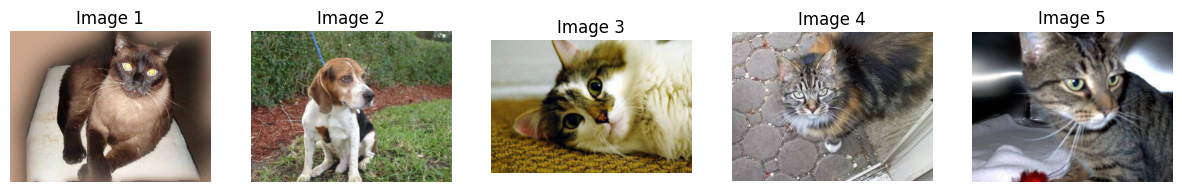

In [10]:
import matplotlib.pyplot as plt

# Show first 5 images
plt.figure(figsize=(15,8))

for i in range(5):

    # Convert BGR to RGB
    img_rgb = cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB)

    plt.subplot(1,5,i+1)
    plt.imshow(img_rgb)
    plt.title(f"Image {i+1}")
    plt.axis("off")

plt.show()

In [11]:
import pandas as pd

# Empty list to store image details
image_details = []

# Extract details
for i, img in enumerate(images):

    height, width, channels = img.shape

    image_details.append({
        "Image No": i + 1,
        "Height": height,
        "Width": width,
        "Channels": channels
    })

# Create DataFrame
df = pd.DataFrame(image_details)

# Show first 10 rows
print(df.head(10))

   Image No  Height  Width  Channels
0         1     375    499         3
1         2     375    499         3
2         3     332    499         3
3         4     181    243         3
4         5     374    500         3
5         6     374    500         3
6         7     373    500         3
7         8     388    499         3
8         9     159    335         3
9        10     281    499         3


In [12]:
# List to store resized images
resized_images = []

# Resize all images
for img in images:

    resized = cv2.resize(img, (224, 224))

    resized_images.append(resized)

print("Total resized images:", len(resized_images))
print("Shape of first resized image:", resized_images[0].shape)

Total resized images: 1100
Shape of first resized image: (224, 224, 3)


In [13]:
# Lists to store converted images
gray_images = []
rgb_images = []
hsv_images = []

# Convert images
for img in resized_images:

    # BGR to Grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # BGR to RGB
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # BGR to HSV
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Store images
    gray_images.append(gray)
    rgb_images.append(rgb)
    hsv_images.append(hsv)

print("Grayscale images:", len(gray_images))
print("RGB images:", len(rgb_images))
print("HSV images:", len(hsv_images))

print("Gray Shape:", gray_images[0].shape)
print("RGB Shape:", rgb_images[0].shape)
print("HSV Shape:", hsv_images[0].shape)

Grayscale images: 1100
RGB images: 1100
HSV images: 1100
Gray Shape: (224, 224)
RGB Shape: (224, 224, 3)
HSV Shape: (224, 224, 3)


In [14]:
# List to store normalized images
normalized_images = []

# Normalize images
for img in resized_images:

    normalized = img / 255.0

    normalized_images.append(normalized)

print("Total normalized images:", len(normalized_images))

# Check pixel range
print("Minimum value:", normalized_images[0].min())
print("Maximum value:", normalized_images[0].max())

# Shape of image
print("Shape:", normalized_images[0].shape)

Total normalized images: 1100
Minimum value: 0.0
Maximum value: 1.0
Shape: (224, 224, 3)


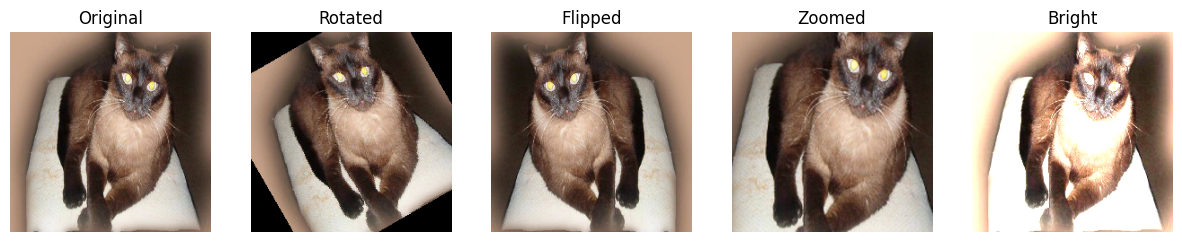

In [15]:
#task 9
from PIL import Image, ImageEnhance
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Take one sample image
img = resized_images[0]

# Convert BGR to RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Convert numpy array to PIL Image
pil_img = Image.fromarray(img_rgb)

# -----------------------------
# 1. Rotation
# -----------------------------
rotated = pil_img.rotate(30)

# -----------------------------
# 2. Horizontal Flip
# -----------------------------
flipped = pil_img.transpose(Image.FLIP_LEFT_RIGHT)

# -----------------------------
# 3. Zoom
# -----------------------------
width, height = pil_img.size

zoomed = pil_img.crop((
    width * 0.1,
    height * 0.1,
    width * 0.9,
    height * 0.9
))

zoomed = zoomed.resize((width, height))

# -----------------------------
# 4. Brightness Adjustment
# -----------------------------
enhancer = ImageEnhance.Brightness(pil_img)

bright = enhancer.enhance(1.8)

# -----------------------------
# Display Images
# -----------------------------
plt.figure(figsize=(15,8))

# Original
plt.subplot(1,5,1)
plt.imshow(pil_img)
plt.title("Original")
plt.axis("off")

# Rotated
plt.subplot(1,5,2)
plt.imshow(rotated)
plt.title("Rotated")
plt.axis("off")

# Flipped
plt.subplot(1,5,3)
plt.imshow(flipped)
plt.title("Flipped")
plt.axis("off")

# Zoomed
plt.subplot(1,5,4)
plt.imshow(zoomed)
plt.title("Zoomed")
plt.axis("off")

# Brightness
plt.subplot(1,5,5)
plt.imshow(bright)
plt.title("Bright")
plt.axis("off")

plt.show()

In [16]:
import cv2
import numpy as np

def preprocess_image(img):

    # 1. Resize
    resized = cv2.resize(img, (224, 224))

    # 2. Convert to Grayscale
    gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)

    # 3. Normalize
    normalized = gray / 255.0

    # 4. Gaussian Blur
    gaussian = cv2.GaussianBlur(gray, (5,5), 0)

    # 5. Median Blur
    median = cv2.medianBlur(gray, 5)

    # 6. Histogram Equalization
    hist_eq = cv2.equalizeHist(gray)

    # 7. CLAHE
    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8,8)
    )

    clahe_img = clahe.apply(gray)

    # 8. Canny Edge Detection
    edges = cv2.Canny(gray, 100, 200)

    # Return all processed outputs
    return {
        "resized": resized,
        "gray": gray,
        "normalized": normalized,
        "gaussian": gaussian,
        "median": median,
        "hist_eq": hist_eq,
        "clahe": clahe_img,
        "edges": edges
    }

# Example usage
processed = preprocess_image(images[0])

print(processed.keys())

dict_keys(['resized', 'gray', 'normalized', 'gaussian', 'median', 'hist_eq', 'clahe', 'edges'])


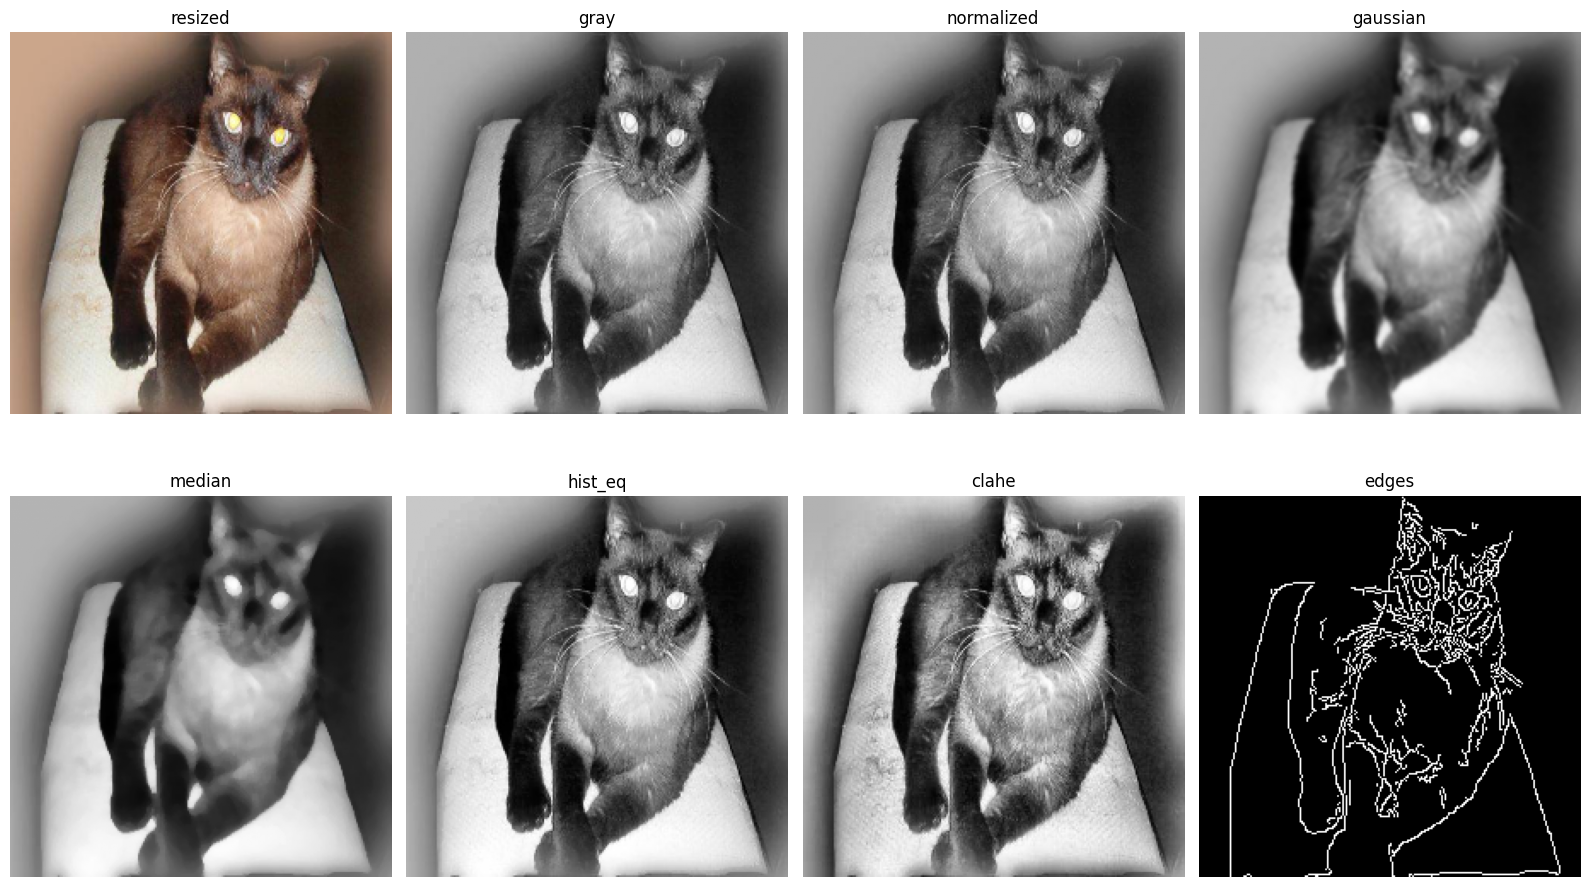

In [17]:
import matplotlib.pyplot as plt

titles = processed.keys()

plt.figure(figsize=(16,10))

for i, (title, img) in enumerate(processed.items()):

    plt.subplot(2,4,i+1)

    if len(img.shape) == 2:
        plt.imshow(img, cmap='gray')
    else:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()


In [18]:
#task 6
# Lists to store blurred images
gaussian_images = []
median_images = []

# Apply blurs
for img in resized_images:

    # Gaussian Blur
    gaussian = cv2.GaussianBlur(img, (5,5), 0)

    # Median Blur
    median = cv2.medianBlur(img, 5)

    gaussian_images.append(gaussian)
    median_images.append(median)

print("Gaussian blurred images:", len(gaussian_images))
print("Median blurred images:", len(median_images))

Gaussian blurred images: 1100
Median blurred images: 1100


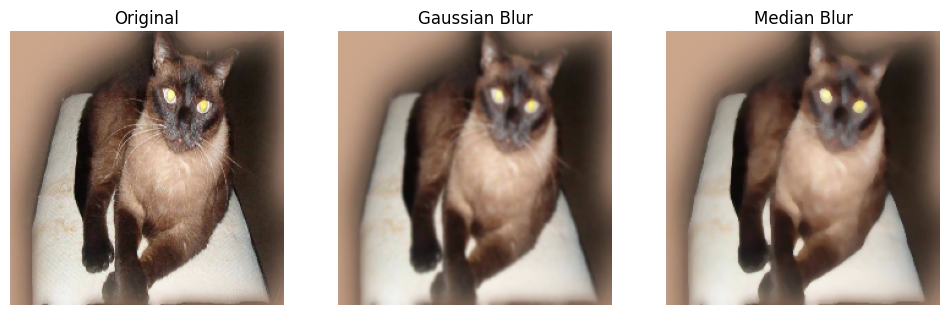

In [19]:
import matplotlib.pyplot as plt

# Convert images to RGB for display
original = cv2.cvtColor(resized_images[0], cv2.COLOR_BGR2RGB)

gaussian = cv2.cvtColor(gaussian_images[0], cv2.COLOR_BGR2RGB)

median = cv2.cvtColor(median_images[0], cv2.COLOR_BGR2RGB)

# Plot images
plt.figure(figsize=(12,5))

# Original
plt.subplot(1,3,1)
plt.imshow(original)
plt.title("Original")
plt.axis("off")

# Gaussian Blur
plt.subplot(1,3,2)
plt.imshow(gaussian)
plt.title("Gaussian Blur")
plt.axis("off")

# Median Blur
plt.subplot(1,3,3)
plt.imshow(median)
plt.title("Median Blur")
plt.axis("off")

plt.show()

In [20]:
#task 7
# Lists to store processed images
hist_eq_images = []
clahe_images = []

# Create CLAHE object
clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8,8)
)

# Apply processing
for img in resized_images:

    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Histogram Equalization
    hist_eq = cv2.equalizeHist(gray)

    # CLAHE
    clahe_img = clahe.apply(gray)

    # Store images
    hist_eq_images.append(hist_eq)
    clahe_images.append(clahe_img)

print("Histogram Equalized images:", len(hist_eq_images))
print("CLAHE images:", len(clahe_images))

Histogram Equalized images: 1100
CLAHE images: 1100


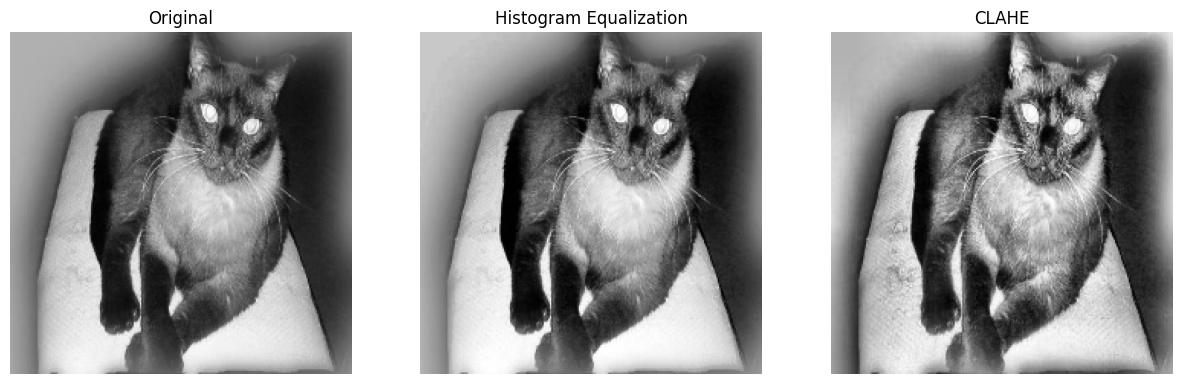

In [21]:
import matplotlib.pyplot as plt

# Original grayscale image
original = cv2.cvtColor(resized_images[0], cv2.COLOR_BGR2GRAY)

# Plot images
plt.figure(figsize=(15,5))

# Original
plt.subplot(1,3,1)
plt.imshow(original, cmap='gray')
plt.title("Original")
plt.axis("off")

# Histogram Equalization
plt.subplot(1,3,2)
plt.imshow(hist_eq_images[0], cmap='gray')
plt.title("Histogram Equalization")
plt.axis("off")

# CLAHE
plt.subplot(1,3,3)
plt.imshow(clahe_images[0], cmap='gray')
plt.title("CLAHE")
plt.axis("off")

plt.show()

In [22]:
#task 8
# List to store edge detected images
edge_images = []

# Apply Canny Edge Detection
for img in resized_images:

    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Detect edges
    edges = cv2.Canny(gray, 100, 200)

    edge_images.append(edges)

print("Edge detected images:", len(edge_images))
print("Shape:", edge_images[0].shape)

Edge detected images: 1100
Shape: (224, 224)


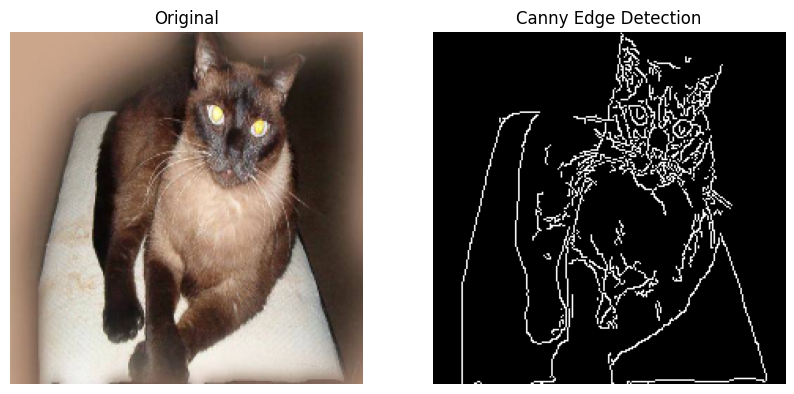

In [23]:
import matplotlib.pyplot as plt

# Original image
original = cv2.cvtColor(resized_images[0], cv2.COLOR_BGR2RGB)

# Edge image
edges = edge_images[0]

# Plot
plt.figure(figsize=(10,5))

# Original
plt.subplot(1,2,1)
plt.imshow(original)
plt.title("Original")
plt.axis("off")

# Edges
plt.subplot(1,2,2)
plt.imshow(edges, cmap='gray')
plt.title("Canny Edge Detection")
plt.axis("off")

plt.show()